# 🐍 ML with python (Class 9): Classification Models

### 🎯 Session Objectives
1. Understand the theoretical foundations of 6 major classification models.
2. Learn how to preprocess data specifically for classification tasks.
3. Implement each model using Python's `scikit-learn` library.
4. Evaluate model performance using Accuracy, Precision, Recall, Confusion Matrices, and ROC-AUC curves.
5. Visualize decision boundaries using Principal Component Analysis (PCA).

### 📊 The Dataset
We will be using the classic **Breast Cancer Wisconsin (Diagnostic) Dataset**.
- **Goal:** Predict whether a breast mass is Malignant (cancerous) or Benign (non-cancerous) based on computed features of a digitized image of a fine needle aspirate (FNA) of a breast mass.
- This is a **Binary Classification** problem.

---
## Part 1: Environment Setup & Library Imports
Before building models, we need our toolkit. We will use `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and `scikit-learn` for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Ignore warnings for cleaner output during the session
import warnings
warnings.filterwarnings('ignore')

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

---
## Part 2: Data Loading and Exploratory Data Analysis (EDA)
Let's load the dataset from `scikit-learn` and inspect it to understand what we are working with. Checking class distribution is crucial to ensure our dataset isn't heavily imbalanced.

Dataset shape (Rows, Columns): (569, 31)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


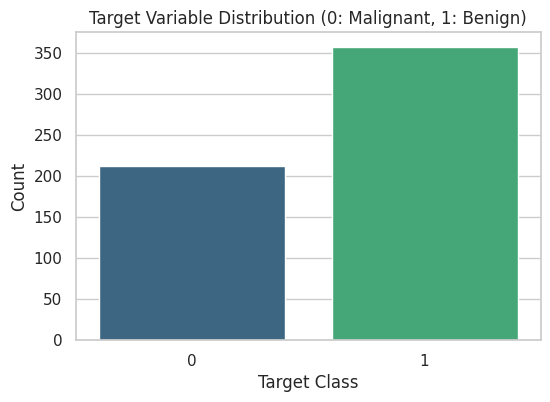

In [2]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0 = malignant, 1 = benign

print(f"Dataset shape (Rows, Columns): {df.shape}\n")
display(df.head())

# Visualize Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Target Variable Distribution (0: Malignant, 1: Benign)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

---
## Part 3: Data Preprocessing
Machine Learning models learn best when data is properly prepared.

1. **Train-Test Split:** We divide our data into a training set (to teach the model) and a test set (to evaluate the model on unseen data).
2. **Feature Scaling (Standardization):** Algorithms like KNN and SVM calculate the geometric distance between data points. If one feature is measured in thousands and another in decimals, the larger feature dominates. Scaling centers the data around a mean of 0 with a standard deviation of 1.

In [3]:
# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete.")
print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Test set size: {X_test_scaled.shape[0]} samples")

Preprocessing Complete.
Training set size: 455 samples
Test set size: 114 samples


### Helper Function for Model Evaluation
To keep our session efficient, let's write a reusable function that will calculate accuracy, print a classification report, and display a confusion matrix for any model we build.

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    """Predicts and evaluates a given machine learning model."""
    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*40}")
    print(f"{model_name.upper()} RESULTS")
    print(f"{'='*40}")
    print(f"Accuracy Score: {acc*100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Malignant (0)', 'Benign (1)'],
                yticklabels=['Malignant (0)', 'Benign (1)'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return y_pred

---
## Model 1: Logistic Regression

**📚 Theory:**
Despite its name, Logistic Regression is a *classification* algorithm. It applies the Sigmoid function to a linear combination of features to map predictions to probabilities between 0 and 1. If the probability is > 0.5, it predicts class 1; otherwise, class 0.

**✅ Pros:** Fast, highly interpretable, provides prediction probabilities, great baseline model.
**❌ Cons:** Assumes a linear relationship between features and the target. Struggles with highly complex, non-linear boundaries.


LOGISTIC REGRESSION RESULTS
Accuracy Score: 98.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



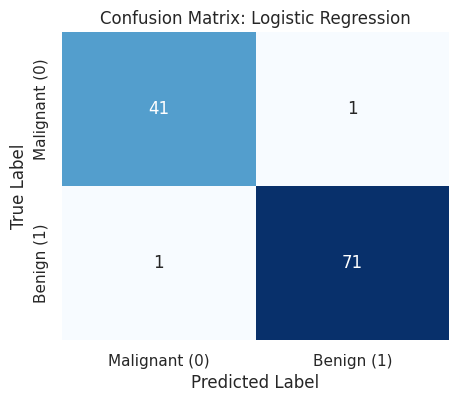

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")

---
## Model 2: K-Nearest Neighbors (KNN)

**📚 Theory:**
KNN is an "instance-based" or "lazy" learner. It doesn't actually learn a mathematical equation during training. Instead, when making a prediction, it looks at the 'K' closest data points in the training set (usually measured by Euclidean distance) and assigns the majority class to the new data point.

**✅ Pros:** Simple to understand, makes no assumptions about data distribution, easily adapts to multi-class problems.
**❌ Cons:** Computationally expensive at test time (must calculate distance to all training points), sensitive to outliers and unscaled data.


K-NEAREST NEIGHBORS RESULTS
Accuracy Score: 95.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



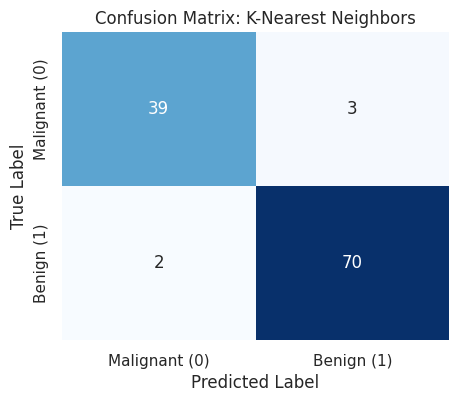

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize model (using k=5 as a starting point)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(knn, X_test_scaled, y_test, "K-Nearest Neighbors")

---
## Model 3: Support Vector Machines (SVM)

**📚 Theory:**
SVM aims to find a "hyperplane" (a line in 2D, a plane in 3D, etc.) that distinctly separates data points of different classes. The algorithm focuses on maximizing the "margin"—the distance between the hyperplane and the closest data points from either class (the Support Vectors).
For non-linear data, SVM uses the **Kernel Trick** (like Radial Basis Function - RBF) to map data into a higher-dimensional space where it *can* be linearly separated.

**✅ Pros:** Highly effective in high-dimensional spaces, robust against overfitting when the margin is large.
**❌ Cons:** Requires careful hyperparameter tuning, slow on very large datasets.


SUPPORT VECTOR MACHINE (SVM) RESULTS
Accuracy Score: 98.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



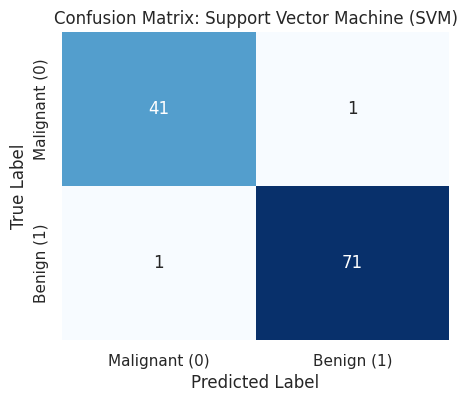

In [7]:
from sklearn.svm import SVC

# Initialize model (using RBF kernel. probability=True enables ROC curve later)
svm = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)

# Train the model
svm.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(svm, X_test_scaled, y_test, "Support Vector Machine (SVM)")

---
## Model 4: Naive Bayes

**📚 Theory:**
Based on Bayes' Theorem, this classifier calculates the probability of a data point belonging to a class based on prior knowledge of conditions. It is called "Naive" because it assumes that all features are entirely independent of one another—an assumption that is rarely true in real life, but surprisingly works very well in practice!

**✅ Pros:** Extremely fast, works great with high-dimensional data (like text classification/NLP).
**❌ Cons:** The assumption of feature independence is a strong limitation; probabilities can sometimes be badly calibrated.


GAUSSIAN NAIVE BAYES RESULTS
Accuracy Score: 92.98%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



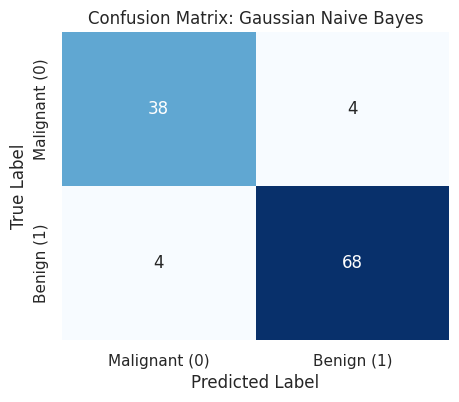

In [8]:
from sklearn.naive_bayes import GaussianNB

# Initialize model (Gaussian assumes features follow a normal distribution)
nb = GaussianNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(nb, X_test_scaled, y_test, "Gaussian Naive Bayes")

---
## Model 5: Decision Trees

**📚 Theory:**
Decision Trees act like a flowchart. They recursively split the data based on feature values that result in the highest "Information Gain" (or lowest Gini Impurity), creating branches and leaves until a final classification is reached.

**✅ Pros:** Extremely interpretable, requires almost no data scaling/preprocessing, handles both numerical and categorical data naturally.
**❌ Cons:** Highly prone to **overfitting** (memorizing the training data) if the tree is allowed to grow too deep.


DECISION TREE RESULTS
Accuracy Score: 92.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



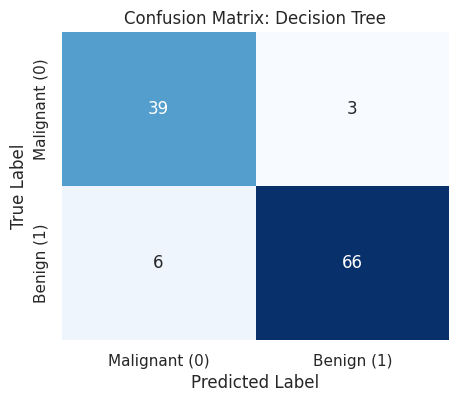

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model (Limiting depth to 5 to prevent severe overfitting)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(dt, X_test_scaled, y_test, "Decision Tree")

---
## Model 6: Random Forest (Ensemble Method)

**📚 Theory:**
Random Forest solves the Decision Tree's overfitting problem by utilizing an **Ensemble** approach called "Bagging". It creates a "forest" of many Decision Trees, where each tree is trained on a random subset of the data and a random subset of features. For classification, the final prediction is decided by majority voting among all the trees.

**✅ Pros:** Exceptionally accurate, robust against overfitting, provides feature importance metrics.
**❌ Cons:** Difficult to interpret visually (a "black box"), computationally heavier than single trees.


RANDOM FOREST RESULTS
Accuracy Score: 95.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



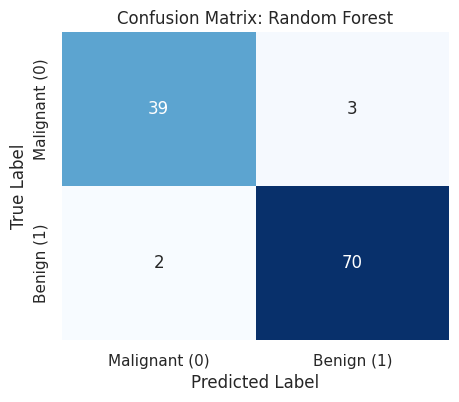

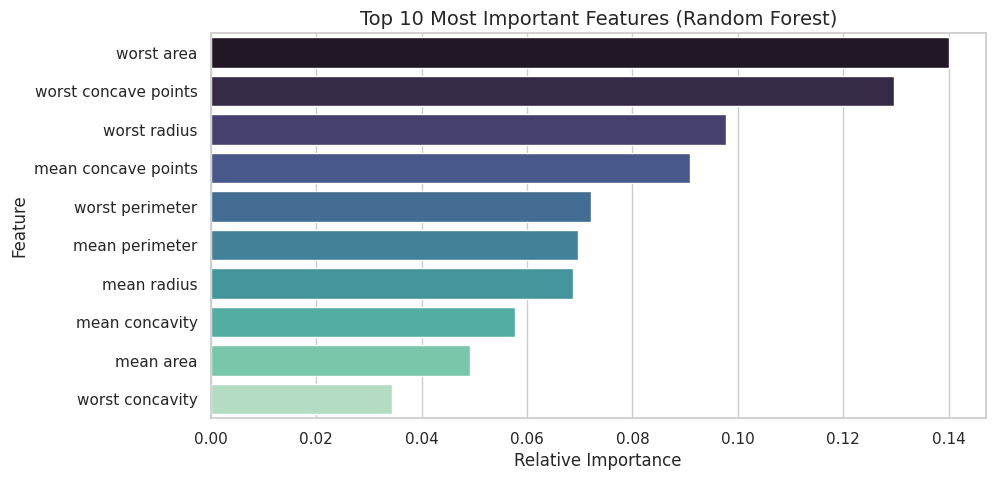

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model (Using 100 individual decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train_scaled, y_train)

# Evaluate
_ = evaluate_model(rf, X_test_scaled, y_test, "Random Forest")

# Bonus: Visualizing Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10

plt.figure(figsize=(10, 5))
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
sns.barplot(x=importances[indices], y=np.array(data.feature_names)[indices], palette="mako")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

---
## Part 4: Model Comparison & ROC Analysis

While Accuracy is great, the **Receiver Operating Characteristic (ROC)** curve and the **Area Under the Curve (AUC)** are standard metrics for evaluating binary classifiers, especially over varying thresholds.
A curve closer to the top-left corner indicates a better model. An AUC of 1.0 represents a perfect model, while 0.5 represents a worthless random guess.

In [ ]:
plt.figure(figsize=(10, 8))

# Dictionary of our trained models
models = {
    'Logistic Regression': log_reg,
    'KNN': knn,
    'SVM': svm,
    'Naive Bayes': nb,
    'Decision Tree': dt,
    'Random Forest': rf
}

for name, model in models.items():
    # Get probability of the positive class (class 1 - Benign)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the random chance baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

---
## Part 5: Visualizing Decision Boundaries (PCA)

Visualizing decision boundaries is highly intuitive, but it requires 2D data. Our breast cancer dataset has 30 features!

To solve this, we will use **Principal Component Analysis (PCA)** to reduce the 30 features down to just 2 principal components. We will then retrain our models on this 2D dataset purely for visualization purposes and plot the boundaries for both the **Training** and **Test** data.

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 1. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 2. Re-initialize models for 2D data
models_2d = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', C=1.0, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train the 2D models
for name, model in models_2d.items():
    model.fit(X_train_pca, y_train)

# 3. Plotting function
def plot_decision_boundaries(X, y, models, title_suffix):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Decision Boundaries ({title_suffix})\nPCA Reduced (2 Components)', fontsize=20, fontweight='bold')

    # Define grid bounds
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    axes = axes.flatten()
    for ax, (name, model) in zip(axes, models.items()):
        # Predict on the meshgrid
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot the contour
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

        # Plot the actual data points
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=25)
        ax.set_title(name, fontsize=14)
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 4. Plot for Training Data
plot_decision_boundaries(X_train_pca, y_train, models_2d, "Training Data")

# 5. Plot for Test Data
plot_decision_boundaries(X_test_pca, y_test, models_2d, "Test Data")